# Job Level Classification

Dự án NLP dự đoán **6 cấp bậc nghề nghiệp** từ tin tuyển dụng.

Quy trình: đọc dữ liệu → làm sạch → EDA → tiền xử lý → huấn luyện → đánh giá → dự đoán dữ liệu mới.

In [1]:
from pathlib import Path
import html
import re

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score,
    classification_report, f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import LinearSVC

RANDOM_STATE = 100

## 1. Đọc và làm sạch dữ liệu

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_PATH = PROJECT_ROOT / "final_project.ods"

columns = ["title", "location", "description", "function", "industry", "career_level"]

def clean_text(value):
    value = html.unescape(str(value)).replace("Â", " ")
    return re.sub(r"\s+", " ", value).strip()

def normalize_location(value):
    value = clean_text(value)
    match = re.search(r"(?:,|\s)\s*([A-Z]{2})$", value)
    return match.group(1) if match else value

data = pd.read_excel(DATA_PATH, dtype=str, engine="odf")
data = data[columns].dropna().drop_duplicates().copy()
for column in columns:
    data[column] = data[column].map(clean_text)
data = data[(data[columns] != "").all(axis=1)].copy()
data["location"] = data["location"].map(normalize_location)
data["combined_text"] = (
    data["title"] + " " + data["title"] + " "
    + data["description"] + " " + data["industry"]
)

print(f"Dữ liệu sau làm sạch: {len(data):,} dòng")
display(data.head(3))

Dữ liệu sau làm sạch: 8,052 dòng


,title,location,description,function,industry,career_level,combined_text
0,Technical Professional Lead - Process,TX,"Responsible for the study, design, and specifi...",production_manufacturing,Machinery and Industrial Facilities Engineering,senior_specialist_or_project_manager,Technical Professional Lead - Process Technica...
1,Cnslt - Systems Eng- Midrange 1,WA,"Participates in design, development and implem...",information_technology_telecommunications,Financial Services,senior_specialist_or_project_manager,Cnslt - Systems Eng- Midrange 1 Cnslt - System...
2,SharePoint Developers and Solution Architects,TX,We are currently in need of Developers who can...,consulting,IT Consulting,senior_specialist_or_project_manager,SharePoint Developers and Solution Architects ...


## 2. Khám phá dữ liệu và phân bố nhãn

,count,percentage
career_level,,
senior_specialist_or_project_manager,4323,53.69
manager_team_leader,2667,33.12
bereichsleiter,958,11.90
director_business_unit_leader,70,0.87
specialist,30,0.37
managing_director_small_medium_company,4,0.05


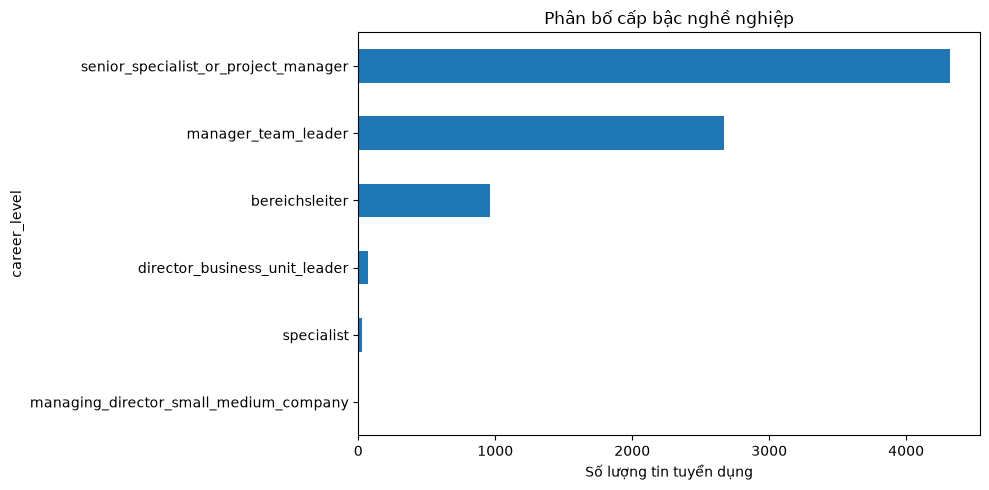

In [3]:
class_counts = data["career_level"].value_counts()
display(pd.DataFrame({
    "count": class_counts,
    "percentage": (class_counts / len(data) * 100).round(2),
}))
class_counts.sort_values().plot(kind="barh", figsize=(10, 5), title="Phân bố cấp bậc nghề nghiệp")
plt.xlabel("Số lượng tin tuyển dụng")
plt.tight_layout()
plt.show()

## 3. Chia train/test

In [4]:
X = data[["combined_text", "location", "function"]]
y = data["career_level"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(X_train):,} mẫu | Test: {len(X_test):,} mẫu")

Train: 6,441 mẫu | Test: 1,611 mẫu


## 4. Xây dựng pipeline và mô hình

In [5]:
def build_preprocessor():
    return ColumnTransformer([
        ("text", TfidfVectorizer(
            stop_words="english", ngram_range=(1, 2), min_df=3,
            max_df=0.98, max_features=50_000, sublinear_tf=True,
        ), "combined_text"),
        ("categorical", OneHotEncoder(handle_unknown="ignore", min_frequency=2),
         ["location", "function"]),
    ])

models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", build_preprocessor()),
        ("classifier", LogisticRegression(
            C=4.0, class_weight="balanced", max_iter=1500, random_state=RANDOM_STATE
        )),
    ]),
    "Linear SVM": Pipeline([
        ("preprocessor", build_preprocessor()),
        ("classifier", LinearSVC(
            C=1.0, class_weight="balanced", random_state=RANDOM_STATE
        )),
    ]),
}

## 5. Huấn luyện và so sánh kết quả

In [6]:
def metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }

results, predictions = {}, {}
baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
results["Baseline"] = metrics(y_test, baseline.predict(X_test))

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    results[name] = metrics(y_test, predictions[name])

comparison = pd.DataFrame(results).T.sort_values("macro_f1", ascending=False)
display(comparison.round(4))

,accuracy,macro_f1,weighted_f1,balanced_accuracy
Linear SVM,0.7871,0.5406,0.7793,0.4917
Logistic Regression,0.7716,0.5286,0.7702,0.5357
Baseline,0.5369,0.1165,0.3752,0.1667


## 6. Đánh giá mô hình tốt nhất

Mô hình tốt nhất: Linear SVM
                                        precision    recall  f1-score   support

                        bereichsleiter       0.55      0.41      0.47       192
         director_business_unit_leader       0.80      0.57      0.67        14
                   manager_team_leader       0.72      0.72      0.72       533
managing_director_small_medium_company       0.00      0.00      0.00         1
  senior_specialist_or_project_manager       0.86      0.92      0.89       865
                            specialist       1.00      0.33      0.50         6

                              accuracy                           0.79      1611
                             macro avg       0.66      0.49      0.54      1611
                          weighted avg       0.78      0.79      0.78      1611



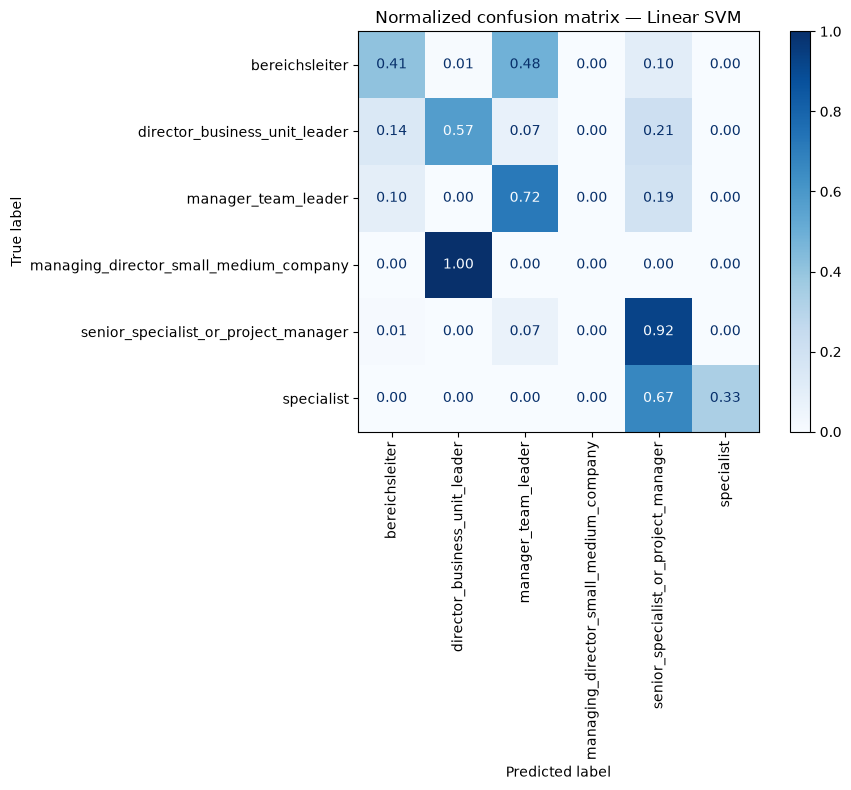

In [7]:
best_name = max(models, key=lambda name: results[name]["macro_f1"])
best_model = models[best_name]
best_prediction = predictions[best_name]
print("Mô hình tốt nhất:", best_name)
print(classification_report(y_test, best_prediction, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_prediction, normalize="true", xticks_rotation="vertical",
    cmap="Blues", values_format=".2f", ax=ax,
)
plt.title(f"Normalized confusion matrix — {best_name}")
plt.tight_layout()
plt.show()

## 7. Nhập input và dự đoán output

In [8]:
job_title = "Senior Software Engineering Manager"
location = "Austin, TX"
description = "Lead engineers, mentor staff and manage project delivery."
job_function = "information_technology_telecommunications"
industry = "Information Technology"

title_clean = clean_text(job_title)
new_job = pd.DataFrame([{
    "combined_text": f"{title_clean} {title_clean} {clean_text(description)} {clean_text(industry)}",
    "location": normalize_location(location),
    "function": clean_text(job_function),
}])
print("Cấp bậc dự đoán:", best_model.predict(new_job)[0])

Cấp bậc dự đoán: manager_team_leader


## 8. Xuất model cho ứng dụng local

Cell này lưu pipeline đã huấn luyện và danh sách gợi ý để `app.py` sử dụng mà không cần huấn luyện lại.

In [9]:
import json
import joblib

ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

joblib.dump(best_model, ARTIFACT_DIR / "job_level_classifier.joblib")

metadata = {
    "selected_model": best_name,
    "job_titles": data["title"].value_counts().head(200).index.tolist(),
    "locations": data["location"].value_counts().head(200).index.tolist(),
    "functions": sorted(data["function"].unique().tolist()),
    "industries": sorted(data["industry"].unique().tolist()),
}
(ARTIFACT_DIR / "metadata.json").write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("Đã xuất model:", ARTIFACT_DIR / "job_level_classifier.joblib")

Đã xuất model: D:\Code\Code dạo\Python\FInal\artifacts\job_level_classifier.joblib


## Kết luận

- Làm sạch và phân tích hơn 8.000 tin tuyển dụng.
- Phân loại 6 cấp bậc nghề nghiệp.
- Sử dụng TF-IDF, One-Hot Encoding và class weighting.
- So sánh baseline, Logistic Regression và Linear SVM.
- Linear SVM đạt accuracy khoảng **78,71%** và macro-F1 khoảng **54,06%**.
- Có thể nhập tin tuyển dụng mới để nhận cấp bậc dự đoán.